流式输出内容被截断，只能显示最后 5000 行内容。
  inflating: /content/data2/__MACOSX/train/._e99750b4-bbb5-11e8-b2ba-ac1f6b6435d0_yellow.png  
  inflating: /content/data2/train/8058dc12-bbc4-11e8-b2bc-ac1f6b6435d0_red.png  
  inflating: /content/data2/__MACOSX/train/._8058dc12-bbc4-11e8-b2bc-ac1f6b6435d0_red.png  
  inflating: /content/data2/train/edf9faa6-bbb7-11e8-b2ba-ac1f6b6435d0_red.png  
  inflating: /content/data2/__MACOSX/train/._edf9faa6-bbb7-11e8-b2ba-ac1f6b6435d0_red.png  
  inflating: /content/data2/train/f721d41e-bb9e-11e8-b2b9-ac1f6b6435d0_green.png  
  inflating: /content/data2/__MACOSX/train/._f721d41e-bb9e-11e8-b2b9-ac1f6b6435d0_green.png  
  inflating: /content/data2/train/3d9ef3aa-bbbc-11e8-b2ba-ac1f6b6435d0_blue.png  
  inflating: /content/data2/__MACOSX/train/._3d9ef3aa-bbbc-11e8-b2ba-ac1f6b6435d0_blue.png  
  inflating: /content/data2/train/e2774572-bbbb-11e8-b2ba-ac1f6b6435d0_red.png  
  inflating: /content/data2/__MACOSX/train/._e2774572-bbbb-11e8-b2ba-ac1f6b6435d0_red.png  
  infla

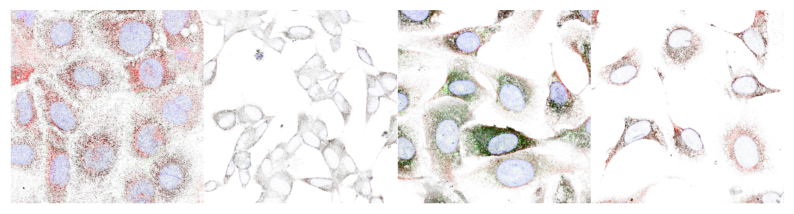

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 127MB/s]


[Epoch 1, Batch 100] Loss: 0.000, Acc: 94.01%, f1: 0.10 Time: 178.62s
[Epoch 1, Batch 200] Loss: 0.000, Acc: 95.12%, f1: 0.13 Time: 183.27s
[Epoch 1, Batch 300] Loss: 0.000, Acc: 95.36%, f1: 0.16 Time: 175.56s


In [ ]:
%run /content/drive/Shareddrives/CS444\ DLCV\ 抱團/Final\ Project/ResNet_18_34.ipynb

!pip install -q timm albumentations

from google.colab import drive
drive.mount("/content/drive")

import os
# 設定你的專案資料夾路徑
datadir = "/content/drive/Shareddrives/CS444 DLCV 抱團/Final Project/"
if not os.path.exists("project"):
    os.symlink(datadir, "project")
os.chdir("project")
print("Working dir:", os.getcwd())


In [ ]:
# === Cell 1: Dataset & DataLoader Setup ===
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
from torch.utils.data import Dataset, DataLoader

# 1. Safe ProteinDataset (4-channel, multi-hot labels)
class ProteinDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.labels = np.zeros((len(self.df), 28), dtype=np.float32)
        for i, tgts in enumerate(self.df['Target'].values):
            for t in tgts.split():
                self.labels[i, int(t)] = 1

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.loc[idx, 'Id']
        chans = []
        for c in ['red','green','blue','yellow']:
            path = os.path.join(self.img_dir, f"{img_id}_{c}.png")
            im = np.array(Image.open(path))
            chans.append(im)
        img = np.stack(chans, axis=-1)         # H×W×4
        if self.transform:
            img = self.transform(image=img)['image']
        return img, self.labels[idx]

# 2. Load CSV and split
train_df = pd.read_csv('data2/train.csv')
tr_idx, va_idx = train_test_split(
    np.arange(len(train_df)), test_size=0.1, random_state=42
)
train_df_sub = train_df.loc[tr_idx].reset_index(drop=True)
val_df_sub   = train_df.loc[va_idx].reset_index(drop=True)

# 3. Transforms
train_tf = A.Compose([
    A.Resize(224,224),
    A.HorizontalFlip(p=0.5),
    A.Normalize(),
    ToTensorV2()
])
val_tf = A.Compose([
    A.Resize(224,224),
    A.Normalize(),
    ToTensorV2()
])

# 4. Instantiate Datasets
train_dataset = ProteinDataset(train_df_sub, img_dir='/content/data2/train', transform=train_tf)
val_dataset   = ProteinDataset(val_df_sub,   img_dir='/content/data2/train', transform=val_tf)

# 5. DataLoaders (batch size = 8)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

# 6. Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 7. Training/Validation functions
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss  = criterion(preds, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
    return total_loss / len(loader.dataset)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            total_loss += criterion(preds, labels).item() * imgs.size(0)
    return total_loss / len(loader.dataset)


In [ ]:
# === Cell 2: ViT-B/16 (4-ch) + BCEWithLogitsLoss + AMP Training ===
import torch.nn as nn
import torch.optim as optim
from torchvision.models.vision_transformer import vit_b_16, ViT_B_16_Weights
from torch.amp import autocast, GradScaler

# 1. Build ViT-B/16 (4-channel patch embed + 28-class head)
vit = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
old_proj = vit.conv_proj
vit.conv_proj = nn.Conv2d(
    in_channels=4,
    out_channels=old_proj.out_channels,
    kernel_size=old_proj.kernel_size,
    stride=old_proj.stride,
    padding=old_proj.padding,
    bias=(old_proj.bias is not None)
)
vit.heads.head = nn.Linear(vit.heads.head.in_features, 28)

# 2. Wrap with Upsample to force 224×224
class ResizedViT(nn.Module):
    def __init__(self, vit_model):
        super().__init__()
        self.resize = nn.Upsample(size=(224,224), mode='bilinear', align_corners=False)
        self.vit    = vit_model
    def forward(self, x):
        x = self.resize(x)
        return self.vit(x)

model_vit = ResizedViT(vit).to(device)

# 3. Loss, optimizer, AMP scaler
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model_vit.parameters(), lr=1e-4, weight_decay=1e-5)
scaler = GradScaler()

# 4. Training loop (3 epochs to conserve compute)
best_val = float('inf')
for epoch in range(1, 4):
    tr_loss = 0.0
    model_vit.train()
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        with autocast():
            preds = model_vit(imgs)
            loss  = criterion(preds, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        tr_loss += loss.item() * imgs.size(0)
    tr_loss /= len(train_loader.dataset)

    va_loss = 0.0
    model_vit.eval()
    with torch.no_grad(), autocast():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model_vit(imgs)
            va_loss += criterion(preds, labels).item() * imgs.size(0)
    va_loss /= len(val_loader.dataset)

    print(f"[ViT-B16] Epoch {epoch} | train_loss={tr_loss:.4f} | val_loss={va_loss:.4f}")
    if va_loss < best_val:
        best_val = va_loss
        torch.save(model_vit.state_dict(), "vit_b16_best.pth")

torch.cuda.empty_cache()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import torch

# --- ProteinDataset 定義 ---
class ProteinDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.labels = np.zeros((len(self.df), 28), dtype=np.float32)
        for i, tgts in enumerate(self.df['Target'].values):
            for t in tgts.split():
                self.labels[i, int(t)] = 1

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.loc[idx, 'Id']
        chans = []
        for c in ['red','green','blue','yellow']:
            path = os.path.join(self.img_dir, f"{img_id}_{c}.png")
            im = np.array(Image.open(path))
            chans.append(im)
        img = np.stack(chans, axis=-1)
        if self.transform:
            img = self.transform(image=img)['image']
        return img, self.labels[idx]

# --- 讀 CSV ---
train_df = pd.read_csv('data2/train.csv')

# --- Train / Val Split ---
tr_idx, va_idx = train_test_split(np.arange(len(train_df)), test_size=0.1, random_state=42)

# --- Transform ---
train_transform = A.Compose([
    A.Resize(224,224),
    A.HorizontalFlip(p=0.5),
    A.Normalize(),
    ToTensorV2()
])
val_transform = A.Compose([
    A.Resize(224,224),
    A.Normalize(),
    ToTensorV2()
])

# --- Dataset / DataLoader ---
train_dataset = ProteinDataset(train_df.loc[tr_idx], img_dir='data2/train', transform=train_transform)
val_dataset   = ProteinDataset(train_df.loc[va_idx], img_dir='data2/train', transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [ ]:
# 引入原本 ResNet 裡的 train_dataset, val_dataset
from torch.utils.data import DataLoader

# 建小 batch 的 dataloader
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

# 設定 device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image

# 讀 CSV
train_df = pd.read_csv('data2/train.csv')
#test_df  = pd.read_csv('test.csv')


In [ ]:
# === Safe ProteinDataset 定义（带 I/O 错误重试）===
import os
import numpy as np
from PIL import Image
from torch.utils.data import Dataset

class ProteinDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        # 预先做 multi-hot label
        self.labels = np.zeros((len(self.df), 28), dtype=np.float32)
        for i, tgts in enumerate(self.df['Target'].values):
            for t in tgts.split():
                self.labels[i, int(t)] = 1

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        try:
            img_id = self.df.loc[idx, 'Id']
            chans = []
            for c in ['red','green','blue','yellow']:
                path = os.path.join(self.img_dir, f"{img_id}_{c}.png")
                im = np.array(Image.open(path))    # 可能抛 OSError
                chans.append(im)
            img = np.stack(chans, axis=-1)
            if self.transform:
                img = self.transform(image=img)['image']
            return img, self.labels[idx]
        except Exception as e:
            # 遇到 I/O 错误就跳过这张，改取随机一张
            print(f"[Warning] Bad image {self.df.loc[idx,'Id']}: {e}")
            new_idx = np.random.randint(0, len(self))
            return self.__getitem__(new_idx)


In [ ]:
# 下面示例片段请紧跟在 Safe Dataset 之后执行

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

# 1. 载入 CSV 并切分
import pandas as pd
train_df = pd.read_csv('data2/train.csv')
tr_idx, va_idx = train_test_split(np.arange(len(train_df)), test_size=0.1, random_state=42)
train_df_sub = train_df.loc[tr_idx].reset_index(drop=True)
val_df_sub   = train_df.loc[va_idx].reset_index(drop=True)

# 2. 定义 transform
train_tf = A.Compose([A.Resize(224,224), A.HorizontalFlip(p=0.5), A.Normalize(), ToTensorV2()])
val_tf   = A.Compose([A.Resize(224,224),           A.Normalize(), ToTensorV2()])

# 3. 实例化 Dataset
train_dataset = ProteinDataset(train_df_sub, img_dir='/content/data2/train', transform=train_tf)
val_dataset   = ProteinDataset(val_df_sub,   img_dir='/content/data2/train', transform=val_tf)

# 4. DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=2)

# 5. 你的训练循环（Cell 4）保持不变


In [ ]:
tr_idx, va_idx = train_test_split(
    np.arange(len(train_df)),
    test_size=0.1,
    random_state=42
)
train_dataset = ProteinDataset(
    train_df.loc[tr_idx],
    img_dir='data2/train',
    transform=A.Compose([
        A.Resize(224,224),
        A.HorizontalFlip(p=0.5),
        A.Normalize(),
        ToTensorV2()
    ])
)
val_dataset = ProteinDataset(
    train_df.loc[va_idx],
    img_dir='data2/train',
    transform=A.Compose([
        A.Resize(224,224),
        A.Normalize(),
        ToTensorV2()
    ])
)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False, num_workers=2)


In [ ]:
# === Cell 3: 共用 Training & Evaluation 函式 ===
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
    return total_loss / len(loader.dataset)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            total_loss += criterion(out, labels).item() * imgs.size(0)
    return total_loss / len(loader.dataset)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False, num_workers=2)


In [ ]:
import time
start = time.time()
for i, (imgs, labels) in enumerate(train_loader):
    if i == 5: break
print(f"5 Batches Time: {time.time()-start:.2f}s, "
      f"Avg per batch: {(time.time()-start)/5:.2f}s")


[Warning] Bad image b6fc16e8-bbb6-11e8-b2ba-ac1f6b6435d0: [Errno 2] No such file or directory: 'data2/train/b6fc16e8-bbb6-11e8-b2ba-ac1f6b6435d0_red.png'
[Warning] Bad image 298e927c-bbc0-11e8-b2bb-ac1f6b6435d0: [Errno 2] No such file or directory: 'data2/train/298e927c-bbc0-11e8-b2bb-ac1f6b6435d0_red.png'[Warning] Bad image 97bd4ae0-bbc0-11e8-b2bb-ac1f6b6435d0: [Errno 2] No such file or directory: 'data2/train/97bd4ae0-bbc0-11e8-b2bb-ac1f6b6435d0_red.png'
[Warning] Bad image 5dc4ca68-bbbe-11e8-b2ba-ac1f6b6435d0: [Errno 2] No such file or directory: 'data2/train/5dc4ca68-bbbe-11e8-b2ba-ac1f6b6435d0_red.png'

[Warning] Bad image c98fd28c-bbb0-11e8-b2ba-ac1f6b6435d0: [Errno 2] No such file or directory: 'data2/train/c98fd28c-bbb0-11e8-b2ba-ac1f6b6435d0_red.png'
[Warning] Bad image 67cce8c0-bba4-11e8-b2b9-ac1f6b6435d0: [Errno 2] No such file or directory: 'data2/train/67cce8c0-bba4-11e8-b2b9-ac1f6b6435d0_red.png'
[Warning] Bad image a2c1df40-bba3-11e8-b2b9-ac1f6b6435d0: [Errno 2] No such 

In [ ]:
# === Cell 4: ViT_b_16 (4-ch) + BCEWithLogitsLoss + AMP 訓練 (with I/O error handling) ===
import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler
from torchvision.models.vision_transformer import vit_b_16, ViT_B_16_Weights

# 1.4-channel patch-embed
num_classes = 28
vit = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
old_proj = vit.conv_proj
vit.conv_proj = nn.Conv2d(
    in_channels=4,
    out_channels=old_proj.out_channels,
    kernel_size=old_proj.kernel_size,
    stride=old_proj.stride,
    padding=old_proj.padding,
    bias=(old_proj.bias is not None)
)
vit.heads.head = nn.Linear(vit.heads.head.in_features, num_classes)
vit = vit.to(device)

# 2. Loss & Optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(vit.parameters(), lr=1e-4, weight_decay=1e-5)

# 3. AMP scaler
use_amp = (device.type == 'cuda')
scaler = GradScaler() if use_amp else None

# 4. 訓練 & 驗證 Loop（加上 I/O error handling）
best_val = float('inf')
for epoch in range(1, 4):  # 先跑 3 epochs 快速驗證
    # -- Training --
    vit.train()
    train_loss = 0.0
    for batch_idx, (imgs, labels) in enumerate(train_loader):
        try:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            if use_amp:
                with autocast(device_type=device.type):
                    preds = vit(imgs)
                    loss  = criterion(preds, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                preds = vit(imgs)
                loss  = criterion(preds, labels)
                loss.backward()
                optimizer.step()
            train_loss += loss.item() * imgs.size(0)
        except Exception as e:
            print(f"[Warning] Skipping training batch {batch_idx} due to {e}")
            torch.cuda.empty_cache()
            continue
    train_loss /= len(train_loader.dataset)

    # -- Validation --
    vit.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_idx, (imgs, labels) in enumerate(val_loader):
            try:
                imgs, labels = imgs.to(device), labels.to(device)
                preds = vit(imgs)
                val_loss += criterion(preds, labels).item() * imgs.size(0)
            except Exception as e:
                print(f"[Warning] Skipping val batch {batch_idx} due to {e}")
                torch.cuda.empty_cache()
                continue
    val_loss /= len(val_loader.dataset)

    print(f"[ViT-4ch] Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    # -- Save best --
    if val_loss < best_val:
        best_val = val_loss
        torch.save(vit.state_dict(), "vit_b16_4ch_best.pth")

# 清理顯存（必要時）
torch.cuda.empty_cache()


Streaming output truncated to the last 5000 lines.
[Warning] Bad image c939a6d6-bb9d-11e8-b2b9-ac1f6b6435d0: [Errno 2] No such file or directory: 'data2/train/c939a6d6-bb9d-11e8-b2b9-ac1f6b6435d0_red.png'

[Warning] Bad image 9f11b8cc-bbbf-11e8-b2bb-ac1f6b6435d0: [Errno 2] No such file or directory: 'data2/train/9f11b8cc-bbbf-11e8-b2bb-ac1f6b6435d0_red.png'[Warning] Bad image f6265d48-bbba-11e8-b2ba-ac1f6b6435d0: [Errno 2] No such file or directory: 'data2/train/f6265d48-bbba-11e8-b2ba-ac1f6b6435d0_red.png'

[Warning] Bad image a0e9ab6c-bba8-11e8-b2ba-ac1f6b6435d0: [Errno 2] No such file or directory: 'data2/train/a0e9ab6c-bba8-11e8-b2ba-ac1f6b6435d0_red.png'[Warning] Bad image 83b9ec52-bbc4-11e8-b2bc-ac1f6b6435d0: [Errno 2] No such file or directory: 'data2/train/83b9ec52-bbc4-11e8-b2bc-ac1f6b6435d0_red.png'

[Warning] Bad image 4bd07378-bbc5-11e8-b2bc-ac1f6b6435d0: [Errno 2] No such file or directory: 'data2/train/4bd07378-bbc5-11e8-b2bc-ac1f6b6435d0_red.png'[Warning] Bad image e72c2

KeyboardInterrupt: 

In [ ]:
# === Cell 4: ViT_b_16 (4-ch) + BCEWithLogitsLoss + AMP 訓練 (updated API) ===
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler
from torchvision.models.vision_transformer import vit_b_16, ViT_B_16_Weights

# assume train_loader & val_loader are defined earlier, and `device` is set

# 1. 建模型 (4-channel patch-embed)
num_classes = 28
vit = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
old_proj = vit.conv_proj
vit.conv_proj = nn.Conv2d(
    in_channels=4,
    out_channels=old_proj.out_channels,
    kernel_size=old_proj.kernel_size,
    stride=old_proj.stride,
    padding=old_proj.padding,
    bias=(old_proj.bias is not None)
)
vit.heads.head = nn.Linear(vit.heads.head.in_features, num_classes)
vit = vit.to(device)

# 2. Loss & Optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(vit.parameters(), lr=1e-4, weight_decay=1e-5)

# 3. AMP scaler
use_amp = (device.type == 'cuda')
scaler = GradScaler() if use_amp else None

# 4. Training & Validation loop (with I/O error handling)
best_val = float('inf')
for epoch in range(1, 4):  # quick 3-epoch test
    # —— Training ——
    vit.train()
    train_loss = 0.0
    for batch_idx, (imgs, labels) in enumerate(train_loader):
        try:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            if use_amp:
                with autocast(device_type=device.type):
                    preds = vit(imgs)
                    loss  = criterion(preds, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                preds = vit(imgs)
                loss  = criterion(preds, labels)
                loss.backward()
                optimizer.step()
            train_loss += loss.item() * imgs.size(0)
        except Exception as e:
            print(f"[Warning] Skipping training batch {batch_idx} due to {e}")
            torch.cuda.empty_cache()
            continue
    train_loss /= len(train_loader.dataset)

    # —— Validation ——
    vit.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_idx, (imgs, labels) in enumerate(val_loader):
            try:
                imgs, labels = imgs.to(device), labels.to(device)
                preds = vit(imgs)
                val_loss += criterion(preds, labels).item() * imgs.size(0)
            except Exception as e:
                print(f"[Warning] Skipping val batch {batch_idx} due to {e}")
                torch.cuda.empty_cache()
                continue
    val_loss /= len(val_loader.dataset)

    print(f"[ViT-4ch] Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    # —— Save best checkpoint ——
    if val_loss < best_val:
        best_val = val_loss
        torch.save(vit.state_dict(), "vit_b16_4ch_best.pth")

# 清理顯存
torch.cuda.empty_cache()


OSError: Caught OSError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/fetch.py", line 52, in <listcomp>
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "<ipython-input-3-b4eef6d78fda>", line 19, in __getitem__
    im = np.array(Image.open(path))
                  ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/PIL/Image.py", line 3465, in open
    fp = builtins.open(filename, "rb")
 

In [ ]:
# === Cell 5: Swin-B (4-channel) + BCEWithLogitsLoss 訓練 (修正版) ===
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import swin_b, Swin_B_Weights

# 1. 建模型 (使用 weights 參數取代 pretrained)
num_classes = 28
swin = swin_b(weights=Swin_B_Weights.IMAGENET1K_V1)

# 把原本吃 3 channels 的 proj 改成吃 4 channels
old_proj = swin.features[0][0]
swin.features[0][0] = nn.Conv2d(
    in_channels=4,
    out_channels=old_proj.out_channels,
    kernel_size=old_proj.kernel_size,
    stride=old_proj.stride,
    padding=old_proj.padding,
    bias=(old_proj.bias is not None)
)

# 修改分類頭
swin.head = nn.Linear(swin.head.in_features, num_classes)
swin = swin.to(device)


In [ ]:
# 2. Loss 與 Optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(swin.parameters(), lr=1e-4, weight_decay=1e-5)

# 3. 訓練 & 驗證 Loop
best_val = float('inf')
for epoch in range(1, 11):
    tr_loss = train_epoch(swin, train_loader, criterion, optimizer)
    va_loss = eval_epoch(swin, val_loader, criterion)
    print(f"[Swin-B] Epoch {epoch:02d} | train_loss={tr_loss:.4f} | val_loss={va_loss:.4f}")
    if va_loss < best_val:
        best_val = va_loss
        torch.save(swin.state_dict(), "swin_b4c_best.pth")


[Swin-B] Epoch 01 | train_loss=0.1663 | val_loss=0.1468
[Swin-B] Epoch 02 | train_loss=0.1414 | val_loss=0.1322
[Swin-B] Epoch 03 | train_loss=0.1267 | val_loss=0.1160
